## Tool definition

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain.tools import tool

@tool
def square_root(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5

@tool → registers the function as a LangChain Tool; the tool's name is taken from the function name (square_route), and the description from the docstring, args schema from type hints.

In [3]:
@tool("square_root")
def tool1(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5

@tool("name") → registers the tool but gives it a custom name — overrides the function name (e.g., using "square_root" fn but tool name "tool1"). Useful when you want the tool name visible to the model to be different from the Python function name.

In [4]:
@tool("square_root", description="Calculate the square root of a number")
def tool1(x: float) -> float:
    return x ** 0.5

What the model sees: tool name + description + args schema.

In [5]:
tool1.invoke({"x": 467})

21.61018278497431

Step 1 — User
  User: "What's the weather in Casablanca tomorrow?"  

Step 2 — Model reads the conversation + the tool CATALOG
  (catalog: name = get_weather, description = "forecast for a city", args = city)  
  model (thinking): "I don't know today's weather... but I have a tool called  
                     get_weather."  
  → outputs: tool_call get_weather(city="Casablanca")  
             ↓  (this is JUST TEXT — a structured request, no data yet!)

Step 3 — LangChain executes the tool  
  → real HTTP/database call → returns "tomorrow: 24°C, sunny"
             ↓  (now there's REAL data)  

Step 4 — Model sees the result and answers  
  → "In Casablanca tomorrow it will be 24°C and sunny ☀️"  

## Adding Tools to agents

1. DETERMINE the model           → init_chat_model(model="...", model_provider="google-genai", api_key=...)
2. DETERMINE the tool (optional) → @tool def search_web(...)
3. DETERMINE the system prompt   → the character/instructions (optional)
4. CREATE the agent              → agent = create_agent(model=..., tools=[...], system_prompt=...)
      └─ the agent is the "worker + instruction sheet + toolbox" COMBINED

In [6]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
import os

agent = create_agent(
    model=init_chat_model(
        model="gemini-3.1-flash-lite",
        model_provider="google-genai",
        api_key=os.getenv("GOOGLE_API_KEY"),
    ),
    tools=[tool1],
    system_prompt="You are an arithmetic wizard. Use your tools to calculate the square root and square of any number."
)


5. DETERMINE the user's message  → question = HumanMessage("...")
6. INVOKE the agent              → response = agent.invoke({"messages": [question]})
7. PRINT the response            → print(response["messages"][-1].text)

In [7]:
from langchain.messages import HumanMessage

question = HumanMessage(content="What is the square root of 467?")

response = agent.invoke(
    {"messages": [question]}
)

print(response['messages'][-1].content)

[{'type': 'text', 'text': 'The square root of 467 is approximately 21.6101827849743.', 'extras': {'signature': 'EnEKbwFpFH0TwiG6L6aN+o5dXq/4pzUdN9rNAA30IdfLDjzn0b1MLCini86xA1KGC6orloEj9QMmx9vO3BTQj2aNBs2mcLpp0qhVIBdT5oU8E4BpEGH+dlVtgOThx8VsobjK6yGumSiakjKV3QkZYUSaew=='}}]


### The tape: 4 messages = 1 invoke
[0] HumanMessage   ← your Post-it  
[1] AIMessage      ← model says NOTHING, only ASKS to use the tool  
[2] ToolMessage    ← the real result (this is tool1.invoke's output!)  
[3] AIMessage      ← model now ANSWERS, grounded in that result  

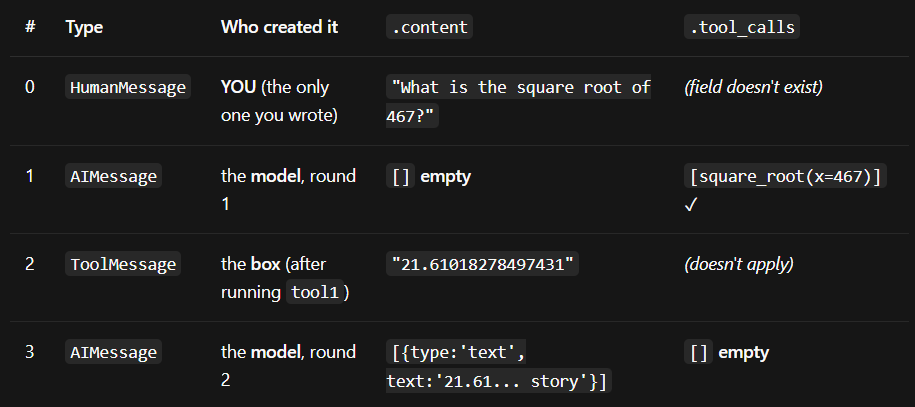

In [8]:
from pprint import pprint

pprint(response['messages'])

[HumanMessage(content='What is the square root of 467?', additional_kwargs={}, response_metadata={}, id='a270c086-a65d-4a5a-9d75-84af9ee05eb5'),
 AIMessage(content=[], additional_kwargs={'function_call': {'name': 'square_root', 'arguments': '{"x": 467}'}, '__gemini_function_call_thought_signatures__': {'call_973841': 'EnEKbwFpFH0TwMbLLwDznihdPYiFJZVBSewI87Pksnegz7tA8j5s/Ou3yxQgMIHuc7ikG7X1R7rzOMYViJVuyYQjo7TMx1wBYddUh+N2U3cFcrEEohKohbKT9zB/HsAA/vM5W+JdILD1CEhVYazu5GoczQ=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0bb20-96e7-7c42-9447-f8cdd1fede09-0', tool_calls=[{'name': 'square_root', 'args': {'x': 467}, 'id': 'call_973841', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 76, 'output_tokens': 16, 'total_tokens': 92, 'input_token_details': {'cache_read': 0}}),
 ToolMessage(content='21.61018278497431', name='square_root', id='b729dd56-e3f6-4f

In [9]:
print(response["messages"][1].tool_calls)

[{'name': 'square_root', 'args': {'x': 467}, 'id': 'call_973841', 'type': 'tool_call'}]


### Mental model in one breath
invoke is a waiter: it takes your 1 message, shows it to the model, the model either (a) tells a story to you → done, or (b) orders tools → the waiter runs them, attaches a ToolMessage receipt via tool_call_id, shows everything to the model again, and only then returns — with the entire tape under response["messages"]. Every element is an object, .tool_calls is the model's order form, content=[] just means "ordering, not talking."